<a href="https://colab.research.google.com/github/tharun-ragu22/rideshare-predictor/blob/main/RideshareML_DataCollection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install env_canada

In [ ]:
import requests
import zipfile

# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# https://docs.ckan.org/en/latest/api/

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"
params = { "id": "private-transportation-companies-summary-and-trip-data"}
package = requests.get(url, params = params).json()

# To get resource data:
for idx, resource in enumerate(package["result"]["resources"]):

       # To get metadata for non datastore_active resources:
       if not resource["datastore_active"]:
           url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
           resource_metadata = requests.get(url).json()
           # From here, you can use the "url" attribute to download this file
           if resource["format"] != "ZIP":
              continue
           print(resource_metadata)
           save_path = resource_metadata['result']['name']

           downloading_url = resource_metadata['result']['url']
           with requests.get(downloading_url, stream=True) as r:
              r.raise_for_status()
              with open(save_path, "wb") as f:
                  for chunk in r.iter_content(chunk_size=8192):
                      if chunk:
                          f.write(chunk)
           print(f"Downloaded {save_path} safely")









{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_last_updated': None, 'cache_url': None, 'created': '2026-03-30T12:56:08.309588', 'datastore_active': False, 'extract_job': 'Airflow: upload_remote_files', 'format': 'ZIP', 'hash': '', 'id': 'de1ea4ce-6626-4e3c-8455-b10ae31fc00f', 'is_preview': 'False', 'last_modified': '2026-03-04T19:06:42', 'metadata_modified': '2026-03-30T12:56:09.228735', 'mimetype': 'application/zip', 'mimetype_inner': None, 'name': 'trips_2018.zip', 'package_id': 'fbac8e59-4883-4252-b73c-4a5caf19126d', 'position': 9, 'resource_type': None, 'size': 27745620, 'state': 'active', 'url': 'https://opendata.toronto.ca/transportation.services/private-transportation-company-dev/trips/trips_2018.zip', 'url_type': None}}
Downloaded trips_2018.zip safely
{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_la

In [ ]:
for i in range(18,27):
  folder = f'trips_20{i}'
  with zipfile.ZipFile(f'/content/{folder}.zip', 'r') as z:
    z.extractall(folder)


In [ ]:

import pandas as pd
import glob
import os

base_path = "/content"

# pattern to match all CSVs inside trips_2018, trips_2019, ..., trips_2026
pattern = os.path.join(base_path, "trips_20*", "*.csv")


csv_files = glob.glob(pattern)

csv_files

['/content/trips_2023/trips_202308.csv',
 '/content/trips_2023/trips_202302.csv',
 '/content/trips_2023/trips_202303.csv',
 '/content/trips_2023/trips_202305.csv',
 '/content/trips_2023/trips_202306.csv',
 '/content/trips_2023/trips_202301.csv',
 '/content/trips_2023/trips_202312.csv',
 '/content/trips_2023/trips_202307.csv',
 '/content/trips_2023/trips_202310.csv',
 '/content/trips_2023/trips_202304.csv',
 '/content/trips_2023/trips_202309.csv',
 '/content/trips_2023/trips_202311.csv',
 '/content/trips_2026/trips_202602.csv',
 '/content/trips_2026/trips_202601.csv',
 '/content/trips_2020/trips_202010.csv',
 '/content/trips_2020/trips_202003.csv',
 '/content/trips_2020/trips_202011.csv',
 '/content/trips_2020/trips_202009.csv',
 '/content/trips_2020/trips_202012.csv',
 '/content/trips_2020/trips_202007.csv',
 '/content/trips_2020/trips_202005.csv',
 '/content/trips_2020/trips_202008.csv',
 '/content/trips_2020/trips_202004.csv',
 '/content/trips_2020/trips_202001.csv',
 '/content/trips

In [ ]:
import pandas as pd
import glob
import os

base_path = "/content"

# pattern to match all CSVs inside trips_2018, trips_2019, ..., trips_2026
pattern = os.path.join(base_path, "trips_20*", "*.csv")

csv_files = glob.glob(pattern)

print(f"Found {len(csv_files)} CSV files")

dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file, usecols=['pickup_hr', 'pickup_ward', 'dropoff_ward', 'waittime_avg', 'duration_avg'])
        dfs.append(df)
        # print('added', file)

    except Exception as e:
        print(f"Error reading {file}: {e}")

# combine all into one dataframe
df = pd.concat(dfs, ignore_index=True)

print("Done. Shape:", df.shape)

Found 98 CSV files
Done. Shape: (20234895, 5)


In [ ]:
len(dfs)

98

In [ ]:
df.head()

,pickup_hr,pickup_ward,dropoff_ward,waittime_avg,duration_avg
0,2023-08-01 00:00:00-04,10 - Spadina-Fort York,10 - Spadina-Fort York,3.69,7.20
1,2023-08-01 00:00:00-04,10 - Spadina-Fort York,13 - Toronto Centre,4.50,11.03
2,2023-08-01 00:00:00-04,10 - Spadina-Fort York,11 - University-Rosedale,3.74,10.31
3,2023-08-01 00:00:00-04,13 - Toronto Centre,10 - Spadina-Fort York,3.38,9.19
4,2023-08-01 00:00:00-04,10 - Spadina-Fort York,09 - Davenport,4.75,13.32


In [ ]:
df['pickup_hr'] = pd.to_datetime(df['pickup_hr'].str[:-3])


In [ ]:
mask = (
    ~df["pickup_ward"].isin(["Not included elsewhere", "Not in Toronto"]) &
    ~df["dropoff_ward"].isin(["Not included elsewhere", "Not in Toronto"]) &
    df["pickup_ward"].notna() &
    df["dropoff_ward"].notna() &
    df["waittime_avg"].notna() &
    df["duration_avg"].notna()



)

count = mask.sum()
print(count)

filtered_traffic = df[mask]
filtered_traffic.head()

6337256


,pickup_hr,pickup_ward,dropoff_ward,waittime_avg,duration_avg
0,2023-08-01,10 - Spadina-Fort York,10 - Spadina-Fort York,3.69,7.20
1,2023-08-01,10 - Spadina-Fort York,13 - Toronto Centre,4.50,11.03
2,2023-08-01,10 - Spadina-Fort York,11 - University-Rosedale,3.74,10.31
3,2023-08-01,13 - Toronto Centre,10 - Spadina-Fort York,3.38,9.19
4,2023-08-01,10 - Spadina-Fort York,09 - Davenport,4.75,13.32


In [ ]:
filtered_traffic.shape

(6337256, 5)

In [ ]:
filtered_traffic.isnull().sum().sort_values(ascending=False)

pickup_hr       0
pickup_ward     0
dropoff_ward    0
waittime_avg    0
duration_avg    0
dtype: int64

In [ ]:
filtered_traffic.waittime_avg.value_counts(dropna=False)

waittime_avg
4.00     70909
3.00     64336
5.00     47137
3.50     42748
4.50     34220
         ...  
25.59        1
19.22        1
19.07        1
21.75        1
21.17        1
Name: count, Length: 2762, dtype: int64

In [ ]:
# Assuming 'df' is your DataFrame and 'column_name' is the target column
df['waittime_avg'].describe()

count    1.537458e+07
mean     4.700828e+00
std      4.791197e+00
min      0.000000e+00
25%      3.270000e+00
50%      4.220000e+00
75%      5.590000e+00
max      8.037790e+03
Name: waittime_avg, dtype: float64

In [ ]:
filtered_traffic["pickup_ward"].value_counts(dropna=False)

pickup_ward
10 - Spadina-Fort York           583355
11 - University-Rosedale         462689
13 - Toronto Centre              450561
09 - Davenport                   348052
08 - Eglinton-Lawrence           318298
12 - Toronto-St. Paul's          313515
05 - York South-Weston           310773
04 - Parkdale-High Park          279268
21 - Scarborough Centre          269561
14 - Toronto-Danforth            265384
03 - Etobicoke-Lakeshore         258070
06 - York Centre                 240195
15 - Don Valley West             230398
19 - Beaches-East York           217373
07 - Humber River-Black Creek    205771
20 - Scarborough Southwest       202593
01 - Etobicoke North             196562
16 - Don Valley East             190934
18 - Willowdale                  182583
17 - Don Valley North            178093
24 - Scarborough-Guildwood       165132
02 - Etobicoke Centre            137181
25 - Scarborough-Rouge Park      114200
22 - Scarborough-Agincourt       109156
23 - Scarborough North      

In [ ]:
filtered_traffic["dropoff_ward"].value_counts(dropna=False)

dropoff_ward
10 - Spadina-Fort York           599864
11 - University-Rosedale         464979
13 - Toronto Centre              448197
08 - Eglinton-Lawrence           345704
09 - Davenport                   325561
12 - Toronto-St. Paul's          318849
05 - York South-Weston           283887
04 - Parkdale-High Park          277302
03 - Etobicoke-Lakeshore         276568
14 - Toronto-Danforth            267799
21 - Scarborough Centre          253908
15 - Don Valley West             244203
06 - York Centre                 242024
19 - Beaches-East York           219763
07 - Humber River-Black Creek    204965
20 - Scarborough Southwest       202071
01 - Etobicoke North             193329
16 - Don Valley East             184845
17 - Don Valley North            180043
18 - Willowdale                  177615
24 - Scarborough-Guildwood       156781
02 - Etobicoke Centre            136045
25 - Scarborough-Rouge Park      116077
23 - Scarborough North           114557
22 - Scarborough-Agincourt 

In [ ]:
filtered_traffic['total_time'] = filtered_traffic['duration_avg']+filtered_traffic['waittime_avg']
filtered_traffic = filtered_traffic.drop(columns=['duration_avg','waittime_avg'])
filtered_traffic.head()


,pickup_hr,pickup_ward,dropoff_ward,total_time
0,2023-08-01,10 - Spadina-Fort York,10 - Spadina-Fort York,10.89
1,2023-08-01,10 - Spadina-Fort York,13 - Toronto Centre,15.53
2,2023-08-01,10 - Spadina-Fort York,11 - University-Rosedale,14.05
3,2023-08-01,13 - Toronto Centre,10 - Spadina-Fort York,12.57
4,2023-08-01,10 - Spadina-Fort York,09 - Davenport,18.07


In [ ]:
filtered_traffic.head()

,pickup_hr,pickup_ward,dropoff_ward,total_time
0,2023-08-01,10 - Spadina-Fort York,10 - Spadina-Fort York,10.89
1,2023-08-01,10 - Spadina-Fort York,13 - Toronto Centre,15.53
2,2023-08-01,10 - Spadina-Fort York,11 - University-Rosedale,14.05
3,2023-08-01,13 - Toronto Centre,10 - Spadina-Fort York,12.57
4,2023-08-01,10 - Spadina-Fort York,09 - Davenport,18.07


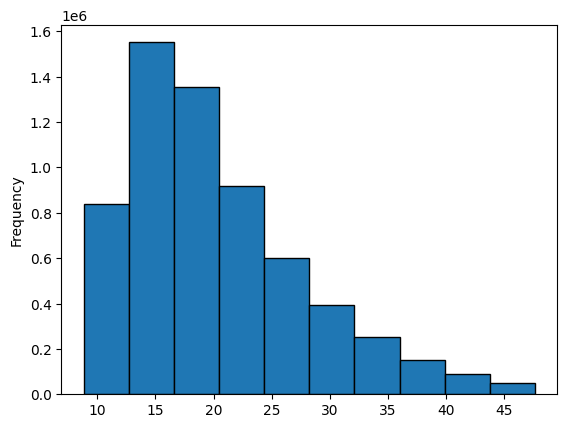

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


q_low = filtered_traffic['total_time'].quantile(0.01)
q_hi  = filtered_traffic['total_time'].quantile(0.99)

df_hist = filtered_traffic[(filtered_traffic['total_time'] < q_hi) & (filtered_traffic['total_time'] > q_low)]

df_hist['total_time'].plot.hist(edgecolor='black')

# Display the plot
plt.show()

In [ ]:
filtered_traffic[filtered_traffic['pickup_hr'].dt.year == 2019]


,pickup_hr,pickup_ward,dropoff_ward,total_time


In [ ]:
import gc

# 1. Remove references
del df
del dfs

# 2. Force the collector to run
gc.collect()

3943

# Get weather data

In [ ]:
import pandas as pd
import asyncio
import nest_asyncio
from env_canada import ECHistoricalRange
from env_canada.ec_historical import get_historical_stations
from datetime import datetime

# Patch the event loop to allow nested loops
nest_asyncio.apply()

async def fetch_weather_data():
    coordinates = ["43.643233", "-79.385993"]

    stations_data = await get_historical_stations(
        coordinates, start_year=2018, end_year=2026, radius=200, limit=100
    )

    stations = pd.DataFrame(stations_data).T

    ec = ECHistoricalRange(
        station_id=int(stations.iloc[0, 2]),
        timeframe="hourly",
        daterange=(datetime(2018, 1, 1), datetime(2026, 3, 1)),
    )

    ec.get_data()
    return ec.df

# Use the loop directly to avoid top-level await SyntaxError
loop = asyncio.get_event_loop()
weather_df = loop.run_until_complete(fetch_weather_data())
# weather_df.head()
print(weather_df.columns)

Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Year',
       'Month', 'Day', 'Time (LST)', 'Flag', 'Temp (°C)', 'Temp Flag',
       'Dew Point Temp (°C)', 'Dew Point Temp Flag', 'Rel Hum (%)',
       'Rel Hum Flag', 'Precip. Amount (mm)', 'Precip. Amount Flag',
       'Wind Dir (10s deg)', 'Wind Dir Flag', 'Wind Spd (km/h)',
       'Wind Spd Flag', 'Visibility (km)', 'Visibility Flag',
       'Stn Press (kPa)', 'Stn Press Flag', 'Hmdx', 'Hmdx Flag', 'Wind Chill',
       'Wind Chill Flag', 'Weather'],
      dtype='str')


In [ ]:
weather_df.shape

(71545, 30)

In [ ]:
weather_df['Visibility (km)'].value_counts(dropna=False)

Visibility (km)
16.1    62895
4.8       948
14.5      943
12.9      932
11.3      889
9.7       855
6.4       853
8.1       811
4.0       389
3.2       243
2.8       225
2.4       224
2.0       221
1.6       197
3.6       184
1.2       175
NaN       144
0.6        98
0.2        90
0.4        89
0.8        76
1.0        56
0.0         8
Name: count, dtype: int64

In [ ]:
weather_df.head()

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Wind Spd Flag,Visibility (km),Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,-79.4,43.63,TORONTO CITY CENTRE,6158359,2018,1,1,00:00,NaN,-16.2,...,NaN,16.1,NaN,102.13,NaN,NaN,NaN,-22.0,NaN,NaN
2018-01-01 01:00:00,-79.4,43.63,TORONTO CITY CENTRE,6158359,2018,1,1,01:00,NaN,-16.8,...,NaN,16.1,NaN,102.10,NaN,NaN,NaN,-20.0,NaN,NaN
2018-01-01 02:00:00,-79.4,43.63,TORONTO CITY CENTRE,6158359,2018,1,1,02:00,NaN,-17.3,...,NaN,16.1,NaN,102.15,NaN,NaN,NaN,-26.0,NaN,NaN
2018-01-01 03:00:00,-79.4,43.63,TORONTO CITY CENTRE,6158359,2018,1,1,03:00,NaN,-17.9,...,NaN,16.1,NaN,102.13,NaN,NaN,NaN,-24.0,NaN,NaN
2018-01-01 04:00:00,-79.4,43.63,TORONTO CITY CENTRE,6158359,2018,1,1,04:00,NaN,-17.2,...,NaN,16.1,NaN,102.09,NaN,NaN,NaN,-21.0,NaN,NaN


In [ ]:
filtered_weather = weather_df[['Temp (°C)', 'Precip. Amount (mm)', 'Visibility (km)']]

total_rows = len(filtered_weather)
rows_with_null = filtered_weather.isnull().any(axis=1).sum()

print(f"{rows_with_null} / {total_rows} rows have at least one null")

494 / 71545 rows have at least one null


In [ ]:
weather_df = None
del weather_df

gc.collect()

551

In [ ]:
filtered_weather['Temp (°C)'] = filtered_weather['Temp (°C)'].interpolate(method='linear')
filtered_weather['Precip. Amount (mm)'] = filtered_weather['Precip. Amount (mm)'].interpolate(method='linear')
filtered_weather['Visibility (km)'] = filtered_weather['Visibility (km)'].interpolate(method='linear')

In [ ]:
filtered_weather.index

DatetimeIndex(['2018-01-01 00:00:00', '2018-01-01 01:00:00',
               '2018-01-01 02:00:00', '2018-01-01 03:00:00',
               '2018-01-01 04:00:00', '2018-01-01 05:00:00',
               '2018-01-01 06:00:00', '2018-01-01 07:00:00',
               '2018-01-01 08:00:00', '2018-01-01 09:00:00',
               ...
               '2026-02-28 15:00:00', '2026-02-28 16:00:00',
               '2026-02-28 17:00:00', '2026-02-28 18:00:00',
               '2026-02-28 19:00:00', '2026-02-28 20:00:00',
               '2026-02-28 21:00:00', '2026-02-28 22:00:00',
               '2026-02-28 23:00:00', '2026-03-01 00:00:00'],
              dtype='datetime64[us]', name='Date/Time (LST)', length=71545, freq=None)

In [ ]:
# df_left has 5 rows of '2026-04-29'
# df_right has '2026-04-29' as a unique index
merged_df = pd.merge(filtered_traffic, filtered_weather, left_on='pickup_hr', right_index=True, how='left')

In [ ]:
print(merged_df.head())

   pickup_hr             pickup_ward              dropoff_ward  total_time  \
0 2023-08-01  10 - Spadina-Fort York    10 - Spadina-Fort York       10.89   
1 2023-08-01  10 - Spadina-Fort York       13 - Toronto Centre       15.53   
2 2023-08-01  10 - Spadina-Fort York  11 - University-Rosedale       14.05   
3 2023-08-01     13 - Toronto Centre    10 - Spadina-Fort York       12.57   
4 2023-08-01  10 - Spadina-Fort York            09 - Davenport       18.07   

   Temp (°C)  Precip. Amount (mm)  Visibility (km)  
0       19.1                  0.0             16.1  
1       19.1                  0.0             16.1  
2       19.1                  0.0             16.1  
3       19.1                  0.0             16.1  
4       19.1                  0.0             16.1  


In [ ]:
merged_df['pickup_hr'].describe()

count                       6337256
mean     2023-08-17 22:05:33.102150
min             2020-01-01 00:00:00
25%             2022-05-11 11:00:00
50%             2023-11-16 10:00:00
75%             2025-01-31 23:00:00
max             2026-02-28 23:00:00
Name: pickup_hr, dtype: object

In [ ]:
merged_df.pickup_hr.dt.hour.value_counts()

pickup_hr
17    377377
18    370044
16    362994
15    348128
19    341470
14    333966
9     321132
8     319062
20    311371
13    309951
12    303267
10    303015
21    301776
11    300353
22    293629
7     279105
23    266579
0     207205
6     187742
1     157340
2     126339
3      83213
5      81690
4      50508
Name: count, dtype: int64

In [ ]:
filtered_traffic['pickup_hr'].describe()

count                       6337256
mean     2023-08-17 22:05:33.102150
min             2020-01-01 00:00:00
25%             2022-05-11 11:00:00
50%             2023-11-16 10:00:00
75%             2025-01-31 23:00:00
max             2026-02-28 23:00:00
Name: pickup_hr, dtype: object

In [ ]:
import asyncio

from env_canada import ECWeather

# Using coordinates (automatic station selection)
ec_coords = ECWeather(coordinates=(43.643233, -79.385993))



# Using station ID - multiple formats supported:
ec_full = ECWeather(station_id="ON/s0000430", language="french")  # Full format
ec_station = ECWeather(station_id="s0000430")  # Station ID only
ec_numeric = ECWeather(station_id="430")  # Numeric only

loop = asyncio.get_event_loop()
loop.run_until_complete(ec_coords.update())


# current conditions
ec_coords.conditions

# # daily forecasts
# ec_coords.daily_forecasts

# # hourly forecasts
# ec_coords.hourly_forecasts

# # alerts (categorised dict with warnings, watches, advisories, statements, endings)
# ec_coords.alerts

# # raw WFS alert feature properties (includes text, area, confidence, impact, etc.)
# ec_coords.alert_features

{'temperature': {'label': 'Temperature', 'unit': 'C', 'value': 15.1},
 'dewpoint': {'label': 'Dew Point', 'unit': 'C', 'value': 8.0},
 'wind_chill': {'label': 'Wind Chill', 'value': None},
 'humidex': {'label': 'Humidex', 'value': None},
 'pressure': {'label': 'Pressure', 'unit': 'kPa', 'value': 100.4},
 'tendency': {'label': 'Tendency', 'unit': 'kPa', 'value': 'rising'},
 'humidity': {'label': 'Humidity', 'unit': '%', 'value': 63},
 'visibility': {'label': 'Visibility', 'unit': 'km', 'value': 24.1},
 'condition': {'label': 'Condition', 'value': 'Mostly Cloudy'},
 'wind_speed': {'label': 'Wind Speed', 'unit': 'km/h', 'value': 28},
 'wind_gust': {'label': 'Wind Gust', 'value': None},
 'wind_dir': {'label': 'Wind Direction', 'value': 'W'},
 'wind_bearing': {'label': 'Wind Bearing', 'unit': 'degrees', 'value': 279},
 'high_temp': {'label': 'High Temperature', 'unit': 'C', 'value': 16},
 'low_temp': {'label': 'Low Temperature', 'unit': 'C', 'value': 6},
 'uv_index': {'label': 'UV Index', '

In [ ]:
merged_df['pickup_hr'].dt.hour

0            0
1            0
2            0
3            0
4            0
            ..
20234821    23
20234822    23
20234833    23
20234836    23
20234837    23
Name: pickup_hr, Length: 6337256, dtype: int32

# Events

In [ ]:
merged_df['dropoff_ward'] = merged_df['dropoff_ward'].str.extract(r'^(\d+)', expand=False).astype(int)

In [ ]:
merged_df['pickup_ward'] = merged_df['pickup_ward'].str.extract(r'^(\d+)', expand=False).astype(int)

In [ ]:
merged_df['event_in_pickup_ward'] = 0
merged_df['event_type'] = 'none'
merged_df['audience'] = 0

In [ ]:
merged_df.head()

,pickup_hr,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience
0,2023-08-01,10,10,10.89,19.1,0.0,16.1,0,none,0
1,2023-08-01,10,13,15.53,19.1,0.0,16.1,0,none,0
2,2023-08-01,10,11,14.05,19.1,0.0,16.1,0,none,0
3,2023-08-01,13,10,12.57,19.1,0.0,16.1,0,none,0
4,2023-08-01,10,9,18.07,19.1,0.0,16.1,0,none,0


In [ ]:
# RAPTORS GAME
from dateutil import parser
import numpy as np
import random

# Get a list of all files in the /content folder
files = glob.glob('/content/nba*.txt')

# Loop through and print file names or read them
for file_path in files:
    print(f"Reading: {file_path}")
    with open(file_path, 'r') as f:
        for line in f:
            dt = parser.parse(line)
            # print(dt.date())

            mask = (merged_df['pickup_ward'] == 10) & (merged_df['pickup_hr'].dt.date == dt.date()) & (merged_df['pickup_hr'].dt.hour.between(19,21))

            mask_size = mask.sum()

            merged_df.loc[mask, 'event_in_pickup_ward'] = 1
            merged_df.loc[mask, 'event_type'] = 'sport'
            merged_df.loc[mask, 'audience'] = random.randint(18500, 19801)




In [ ]:
merged_df[merged_df['event_in_pickup_ward'] == 1].head(50)

,pickup_hr,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience


In [ ]:
# BLUE JAYS GAME
from dateutil import parser
import numpy as np

# Get a list of all files in the /content folder
files = glob.glob('/content/mlb*.txt')

# Loop through and print file names or read them
for file_path in files:

    with open(file_path, 'r') as f:
        for line in f:
            dt = parser.parse(line)
            print(dt)
            weekday = dt.isoweekday()
            begin_hr = None

            if weekday == 7:
              begin_time = 13
            elif weekday == 6:
              begin_time = 15
            else:
              begin_time = 19

            mask = (merged_df['pickup_ward'] == 10) & (merged_df['pickup_hr'].dt.date == dt.date()) & (merged_df['pickup_hr'].dt.hour.between(begin_time,begin_time+3))

            mask_size = mask.sum()

            merged_df.loc[mask, 'event_in_pickup_ward'] = 1
            merged_df.loc[mask, 'event_type'] = 'baseball'

            game_year = dt.year
            audience_lower_bound = None
            audience_upper_bound = None
            if game_year == 2022:
              if dt.month < 5:
                audience_lower_bound = 20000
                audience_upper_bound = 25000
              elif dt.month < 9:
                audience_lower_bound = 25000
                audience_upper_bound = 30000
              else:
                audience_lower_bound = 40000
                audience_upper_bound = 45000

            elif game_year == 2023:
              audience_lower_bound = 35000
              audience_upper_bound = 41000
            elif game_year == 2024:
              audience_lower_bound = 30000
              audience_upper_bound = 40000
            elif game_year == 2025:
              audience_lower_bound = 33700
              audience_upper_bound = 40000


            merged_df.loc[mask, 'audience'] = random.randint(audience_lower_bound, audience_upper_bound)

In [ ]:
merged_df.shape

(6337256, 10)

In [ ]:
merged_df.to_csv('final_data.csv', index=False)

from google.colab import files

# To download a specific file, e.g., 'data.csv'
files.download('final_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualization

In [ ]:
!pip install osmnx geopandas folium requests

import folium
import geopandas as gpd
import requests
import json

In [ ]:

import requests, json

base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Get package metadata
pkg = requests.get(
    base_url + "/api/3/action/package_show",
    params={"id": "city-wards"}
).json()

# Find the first datastore-active resource
resource_id = None
for r in pkg["result"]["resources"]:
    if r.get("datastore_active"):
        resource_id = r["id"]
        break

if not resource_id:
    raise ValueError("No datastore-active resource found")

# Page through all records (datastore_search caps at 100 by default)
all_records = []
offset = 0
limit  = 500

while True:
    resp = requests.get(
        base_url + "/api/3/action/datastore_search",
        params={"id": resource_id, "limit": limit, "offset": offset}
    ).json()
    batch = resp["result"]["records"]
    all_records.extend(batch)
    if len(batch) < limit:
        break
    offset += limit

# Build a GeoJSON FeatureCollection from the geometry column
features = []
for rec in all_records:
    try:
        geom = json.loads(rec["geometry"])
    except (KeyError, json.JSONDecodeError):
        continue
    features.append({
        "type": "Feature",
        "geometry": geom,
        "properties": {
            "ward_num":  rec.get("AREA_SHORT_CODE", "?"),
            "ward_name": rec.get("AREA_NAME", "?"),
        }
    })

ward_geojson = {"type": "FeatureCollection", "features": features}
print(f"Built {len(features)} ward features")


In [ ]:
import folium
from folium import GeoJson, GeoJsonTooltip

m = folium.Map(
    location=[43.718, -79.380],
    zoom_start=11,
    tiles="CartoDB positron"
)

GeoJson(
    ward_geojson,
    name="City Wards",
    style_function=lambda _: {
        "fillColor":   "#378ADD",
        "color":        "#0C447C",
        "weight":        1.2,
        "fillOpacity":  0.35,
    },
    highlight_function=lambda _: {
        "fillColor":   "#D85A30",
        "color":        "#993C1D",
        "weight":        2,
        "fillOpacity":  0.6,
    },
    tooltip=GeoJsonTooltip(
        fields=["ward_num", "ward_name"],
        aliases=["Ward", "Name"],
        localize=True,
        sticky=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)

# Display inline in Colab
from IPython.display import display
display(m)

In [ ]:
!pip install geopandas fiona -q

import requests, json, zipfile, io
import geopandas as gpd


In [ ]:
# Get the direct URL for the SHP zip
pkg_subway = requests.get(
    base_url + "/api/3/action/package_show",
    params={"id": "ttc-subway-shapefiles"}
).json()

shp_url = None
for r in pkg_subway["result"]["resources"]:
    if r.get("format", "").upper() == "SHP":
        shp_url = r["url"]
        break

print("Downloading:", shp_url)

# Download zip into memory and open with geopandas
resp = requests.get(shp_url)
z = zipfile.ZipFile(io.BytesIO(resp.content))
print("Files in zip:", z.namelist())

# Extract to a temp folder and read
z.extractall("/tmp/ttc_subway")

# Find the .shp file inside
import glob
shp_file = glob.glob("/tmp/ttc_subway/**/*.shp", recursive=True)[0]
print("Reading:", shp_file)

gdf = gpd.read_file(shp_file)
print(gdf.columns.tolist())
print(gdf.head())

In [ ]:
# Make sure CRS is WGS84
if gdf.crs and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Build GeoJSON with normalised property names
subway_geojson = json.loads(gdf.to_json())
for feat in subway_geojson["features"]:
    p = feat["properties"]
    p["line_num"]  = str(int(p["RID"]))        # "1", "2", "3", "4"
    p["line_name"] = p["ROUTE_NAME"]

def style_fn(feature):
    line_num = feature["properties"]["line_num"]
    return {
        "color":   LINE_COLOURS.get(line_num, "#888780"),
        "weight":  4,
        "opacity": 0.9,
    }

In [ ]:
# 1. How many features?
print("Feature count:", len(subway_geojson["features"]))

# 2. Check the first feature's geometry and properties
first = subway_geojson["features"][0]
print("Geometry type:", first["geometry"]["type"])
print("First coordinate:", first["geometry"]["coordinates"][0])
print("Properties:", first["properties"])

# 3. Check the map object has the subway layer
print("\nLayers on map m:")
for key, val in m._children.items():
    print(" ", key, "->", type(val).__name__)

In [ ]:
import osmnx as ox
# 1. Fetch Ward Boundaries from OSM
# Toronto wards are defined as administrative boundaries at level 9
print("Fetching ward boundaries from OSM...")
ward_tags = {"boundary": "administrative", "admin_level": "9"}
wards_gdf = ox.features_from_place("Toronto, Ontario, Canada", tags=ward_tags)

# Filter for polygons to avoid noise (sometimes nodes are included)
wards_gdf = wards_gdf[wards_gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

# 2. Fetch Subway Stations and Bus Routes
print("Fetching transit data...")
subway_tags = {"railway": "station", "station": "subway"}
bus_route_tags = {"route": "bus"}

subway_stations = ox.features_from_place("Toronto, Ontario", subway_tags)

In [ ]:
print("Fetching bus stops from OSM... this might take a minute.")
bus_stop_tags = {"highway": "bus_stop"}

# Fetch bus stops in Toronto
bus_stops = ox.features_from_place("Toronto, Ontario", bus_stop_tags)

# Filter to ensure we only have Point geometries
bus_stops = bus_stops[bus_stops.geometry.type == 'Point']

print(f"Found {len(bus_stops)} bus stops.")

In [ ]:
print("Fetching transit infrastructure from OSM...")

# Instead of querying relations which are complex, we query for ways tagged with transit usage
# or infrastructure typically used by these routes.
transit_tags = {
    "railway": ["tram", "light_rail"],
    "busway": True,
    "highway": ["bus_guideway"]
}

try:
    route_lines = ox.features_from_place("Toronto, Ontario", transit_tags)
    # Filter to keep only the geometries that can be drawn as lines
    route_lines = route_lines[route_lines.geometry.type.isin(['LineString', 'MultiLineString'])]
    print(f"Found {len(route_lines)} infrastructure segments.")
except Exception as e:
    print(f"Alternative fetch failed: {e}")
    # Fallback to an empty GeoDataFrame to avoid crashing downstream cells
    import pandas as pd
    from shapely.geometry import LineString
    import geopandas as gpd
    route_lines = gpd.GeoDataFrame(columns=['geometry', 'name', 'ref'], geometry='geometry', crs="EPSG:4326")


In [ ]:
sc_route_lines = ox.features_from_place("Scarborough, Ontario", transit_tags)
# Filter to keep only the geometries that can be drawn as lines
sc_route_lines = sc_route_lines[sc_route_lines.geometry.type.isin(['LineString', 'MultiLineString'])]
print(f"Found {len(sc_route_lines)} infrastructure segments.")

In [ ]:
sc_route_lines

In [ ]:
# Start fresh — create a new map object
m = folium.Map(
    location=[43.718, -79.380],
    zoom_start=11,
    tiles="CartoDB positron"
)

# --- Wards ---
folium.GeoJson(
    ward_geojson,
    name="City Wards",
    style_function=lambda _: {
        "fillColor":  "#378ADD",
        "color":       "#0C447C",
        "weight":       1.2,
        "fillOpacity": 0.25,
    },
    highlight_function=lambda _: {
        "fillColor":  "#D85A30",
        "color":       "#993C1D",
        "weight":       2,
        "fillOpacity": 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["ward_num", "ward_name"],
        aliases=["Ward", "Name"],
        sticky=True,
    ),
).add_to(m)

# --- Subway lines ---
LINE_COLOURS = {
    "1": "#FFCD00",
    "2": "#009B77",
    "3": "#0060A9",
    "4": "#800080",
}

def subway_style(feature):
    line_num = feature["properties"]["line_num"]
    return {
        "color":   LINE_COLOURS.get(line_num, "#888780"),
        "weight":  5,
        "opacity": 1.0,
    }

folium.GeoJson(
    subway_geojson,
    name="TTC Subway Lines",
    style_function=subway_style,
    tooltip=folium.GeoJsonTooltip(
        fields=["line_num", "line_name"],
        aliases=["Line", "Name"],
        sticky=True,
    ),
).add_to(m)

# Add Subway Stations
for _, row in subway_stations.iterrows():
    if row.geometry.type == 'Point':
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color='#D32F2F',
            fill=True,
            tooltip=row.get('name', 'Subway Station')
        ).add_to(m)

# Create a FeatureGroup for bus stops so it can be toggled in the layer control
bus_layer = folium.FeatureGroup(name="TTC Bus Stops", show=False)

for _, row in bus_stops.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2,
        color='#9E9E9E',
        fill=True,
        fill_opacity=0.6,
        tooltip=row.get('name', 'Bus Stop')
    ).add_to(bus_layer)

bus_layer.add_to(m)

# Add the routes to the existing map 'm'
# We'll create a separate layer for them

route_layer = folium.FeatureGroup(name="Bus & Streetcar Routes", show=False)

def route_style(feature):
    # Differentiate streetcars (trams) from buses if possible
    is_streetcar = feature.get('properties', {}).get('route') in ['streetcar', 'tram']
    return {
        "color": "#FF5722" if is_streetcar else "#9E9E9E",
        "weight": 2,
        "opacity": 0.6
    }

folium.GeoJson(
    route_lines,
    style_function=route_style,
    tooltip=folium.GeoJsonTooltip(fields=['name', 'ref'], aliases=['Route:', 'Number:'])
).add_to(route_layer)

folium.GeoJson(
    sc_route_lines,
    style_function=route_style,
    tooltip=folium.GeoJsonTooltip(fields=['name', 'ref'], aliases=['Route:', 'Number:'])
).add_to(route_layer)

route_layer.add_to(m)


# LayerControl added AFTER all layers so it sees everything
folium.LayerControl().add_to(m)

from IPython.display import display
display(m)